In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

print("--- 1. Przygotowanie Danych: TARGET_FAST_TRACK ---")

# 1. Wczytanie pliku
df_final = pd.read_parquet('flight_data_ml_ready.parquet')

# 2. Separacja zmiennej docelowej (y) - TYM RAZEM FAST TRACK
y = df_final['TARGET_FAST_TRACK']
target_cols = [col for col in df_final.columns if col.startswith('TARGET_')]
X = df_final.drop(columns=target_cols)

# 3. Oczyszczanie nazw kolumn
X = X.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))

# 4. Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dane gotowe! Fast Track kupiło: {sum(y)} osób z {len(y)} wszystkich wierszy.")
print(f"Zbiór treningowy: {X_train.shape[0]} wierszy, Zbiór testowy: {X_test.shape[0]} wierszy.")

--- 1. Przygotowanie Danych: TARGET_FAST_TRACK ---
Dane gotowe! Fast Track kupiło: 8019 osób z 527947 wszystkich wierszy.
Zbiór treningowy: 422357 wierszy, Zbiór testowy: 105590 wierszy.


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

print("--- 2. Trenowanie Modelu: Random Forest (Fast Track) ---")

rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("\n[RAPORT KLASYFIKACJI - Random Forest]:")
print(classification_report(y_test, y_pred_rf, target_names=['Brak Fast Track (0)', 'Kupi Fast Track (1)']))

--- 2. Trenowanie Modelu: Random Forest (Fast Track) ---

[RAPORT KLASYFIKACJI - Random Forest]:
                     precision    recall  f1-score   support

Brak Fast Track (0)       0.99      0.73      0.84    103986
Kupi Fast Track (1)       0.03      0.58      0.06      1604

           accuracy                           0.73    105590
          macro avg       0.51      0.65      0.45    105590
       weighted avg       0.98      0.73      0.83    105590



In [3]:
import xgboost as xgb
from sklearn.metrics import precision_recall_curve

print("--- 3. Trenowanie Modelu: XGBoost (Fast Track + Threshold Tuning) ---")

pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

xgb_model = xgb.XGBClassifier(
    n_estimators=150, max_depth=6, learning_rate=0.1,
    scale_pos_weight=pos_weight, random_state=42, n_jobs=-1, eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# Szukanie progu dla Fast Track
y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_xgb)

# Cel: Precyzja 30% (możesz obniżyć do 0.20, jeśli Fast Track jest bardzo rzadki)
target_precision = 0.30
try:
    optimal_idx = np.where(precisions >= target_precision)[0][0]
    optimal_threshold = thresholds[optimal_idx]
except IndexError:
    optimal_idx = np.argmax(precisions)
    optimal_threshold = thresholds[optimal_idx]

y_pred_xgb_optimal = (y_probs_xgb >= optimal_threshold).astype(int)

print(f"Ustalono nowy próg decyzyjny dla Fast Track: {optimal_threshold*100:.1f}%")
print("\n[RAPORT KLASYFIKACJI - XGBoost (Threshold Tuned)]:")
print(classification_report(y_test, y_pred_xgb_optimal, target_names=['Brak Fast Track (0)', 'Kupi Fast Track (1)']))

--- 3. Trenowanie Modelu: XGBoost (Fast Track + Threshold Tuning) ---
Ustalono nowy próg decyzyjny dla Fast Track: 87.4%

[RAPORT KLASYFIKACJI - XGBoost (Threshold Tuned)]:
                     precision    recall  f1-score   support

Brak Fast Track (0)       0.99      1.00      0.99    103986
Kupi Fast Track (1)       0.30      0.01      0.03      1604

           accuracy                           0.98    105590
          macro avg       0.64      0.51      0.51    105590
       weighted avg       0.97      0.98      0.98    105590



--- 4. Trenowanie Modelu: LightGBM (Fast Track) ---
[LightGBM] [Info] Number of positive: 6415, number of negative: 415942
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021292 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1847
[LightGBM] [Info] Number of data points in the train set: 422357, number of used features: 363
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.015189 -> initscore=-4.171907
[LightGBM] [Info] Start training from score -4.171907

[RAPORT KLASYFIKACJI - LightGBM]:
                     precision    recall  f1-score   support

Brak Fast Track (0)       0.99      0.67      0.80    103986
Kupi Fast Track (1)       0.03      0.71      0.06      1604

           accuracy                           0.67    105590
          macro avg       0.51      0.69      0.43    105590
       weighted avg       0.98      0.67      

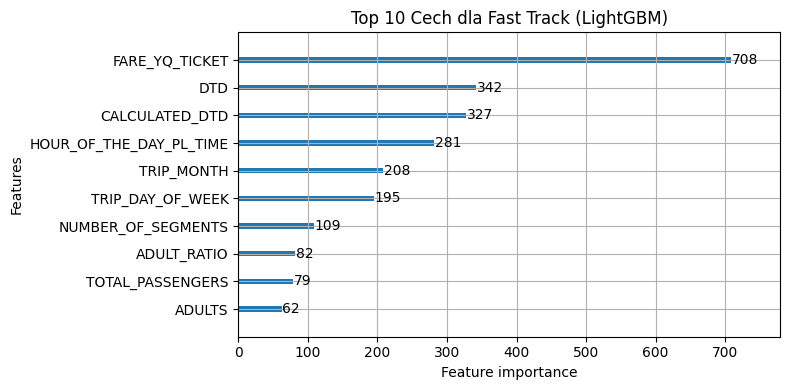

In [4]:
import lightgbm as lgb

print("--- 4. Trenowanie Modelu: LightGBM (Fast Track) ---")

lgb_model = lgb.LGBMClassifier(
    n_estimators=200, learning_rate=0.05, is_unbalance=True, random_state=42, n_jobs=-1
)
lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)
print("\n[RAPORT KLASYFIKACJI - LightGBM]:")
print(classification_report(y_test, y_pred_lgb, target_names=['Brak Fast Track (0)', 'Kupi Fast Track (1)']))

lgb.plot_importance(lgb_model, max_num_features=10, importance_type='split', 
                    figsize=(8, 4), title='Top 10 Cech dla Fast Track (LightGBM)')
plt.tight_layout()
plt.show()

In [5]:
from catboost import CatBoostClassifier

print("--- 5. Trenowanie Modelu: CatBoost (Fast Track) ---")

cat_model = CatBoostClassifier(
    iterations=200, learning_rate=0.1, depth=6,
    auto_class_weights='Balanced', random_seed=42, verbose=0
)
cat_model.fit(X_train, y_train)

y_pred_cat = cat_model.predict(X_test)
print("\n[RAPORT KLASYFIKACJI - CatBoost]:")
print(classification_report(y_test, y_pred_cat, target_names=['Brak Fast Track (0)', 'Kupi Fast Track (1)']))

--- 5. Trenowanie Modelu: CatBoost (Fast Track) ---

[RAPORT KLASYFIKACJI - CatBoost]:
                     precision    recall  f1-score   support

Brak Fast Track (0)       0.99      0.68      0.80    103986
Kupi Fast Track (1)       0.03      0.69      0.06      1604

           accuracy                           0.68    105590
          macro avg       0.51      0.68      0.43    105590
       weighted avg       0.98      0.68      0.79    105590



--- 6. Wyjaśnialność Modelu (SHAP) ---


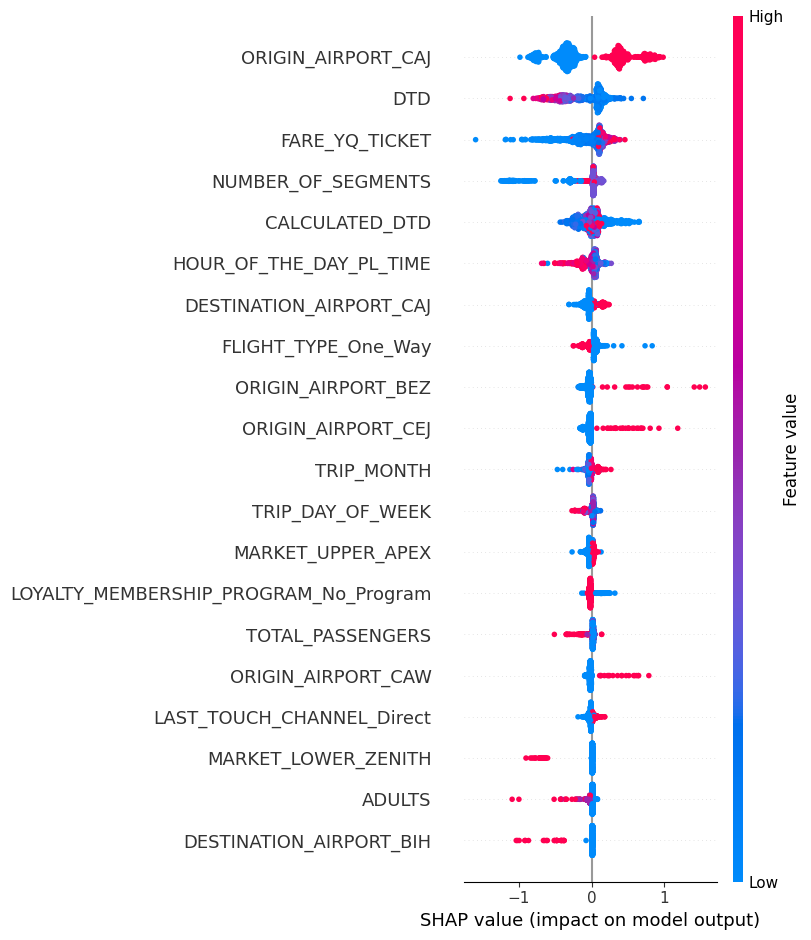

In [6]:
import shap

print("--- 6. Wyjaśnialność Modelu (SHAP) ---")
X_sample = X_test.head(1000)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample)